In [ ]:
using LorenzParameterEstimation
using Plots, Random, Statistics, LinearAlgebra
using StatsBase  
using PlotlyJS
using Revise
using Plots

In [4]:
function plot_param_history(res_test, base_params_test)
    param_hist = res_test.param_history
    σ_hist = [p.σ for p in param_hist]
    ρ_hist = [p.ρ for p in param_hist]
    β_hist = [p.β for p in param_hist]
    epochs = 1:length(param_hist)

    σ_true = base_params_test.σ
    ρ_true = base_params_test.ρ
    β_true = base_params_test.β

    plt_σ = Plots.plot(
        epochs, σ_hist; label="σ", color=:blue, linewidth=2,
        xlabel="Epoch", ylabel="σ Value", legend=:topright,
        title="σ Evolution During Training"
    )
    Plots.hline!(plt_σ, [σ_true]; label="σ (correct)", color=:black, linestyle=:dash, linewidth=2)

    plt_ρ = Plots.plot(
        epochs, ρ_hist; label="ρ", color=:red, linewidth=2,
        xlabel="Epoch", ylabel="ρ Value", legend=:topright,
        title="ρ Evolution During Training"
    )
    Plots.hline!(plt_ρ, [ρ_true]; label="ρ (correct)", color=:black, linestyle=:dash, linewidth=2)

    plt_β = Plots.plot(
        epochs, β_hist; label="β", color=:green, linewidth=2,
        xlabel="Epoch", ylabel="β Value", legend=:topright,
        title="β Evolution During Training"
    )
    Plots.hline!(plt_β, [β_true]; label="β (correct)", color=:black, linestyle=:dash, linewidth=2)

    return Plots.plot(plt_σ, plt_ρ, plt_β, layout=(1,3), size=(1200, 350))
end


plot_param_history (generic function with 1 method)

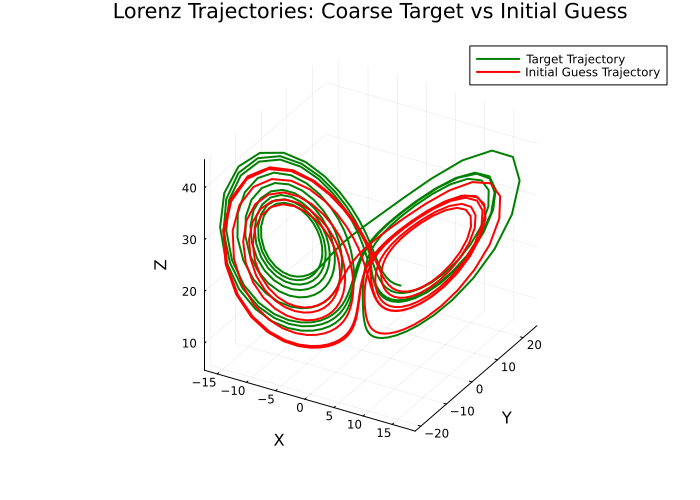

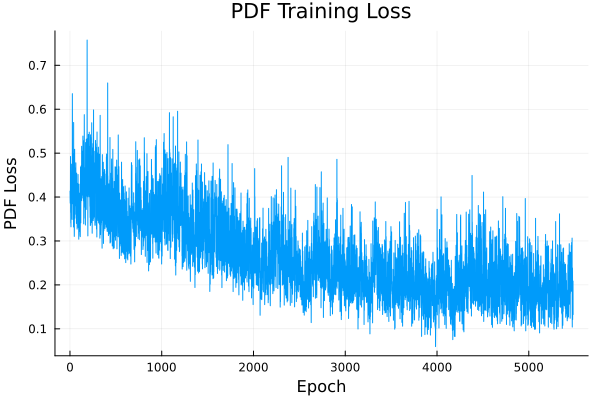

In [5]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 32  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ  # <- choose your target bandwidth here
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 10
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h


cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42)
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
res_test = train_statistics(
    init_params;
    target = target_pdf,
    stats  = (:pdf3d,),
    optimizer = Optimisers.Adam(1e-3),                 # <= was 3e-3
    update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
    epochs = 10_000,
    refresh = 5,                                      
    early_stopping_patience = 1500,
    early_stopping_min_delta = 1e-6,
    rel_delta = 1e-5,
    cfg = cfg_test,
    verbose = true,
    gradient_verbose = false,
    gradient_clip_norm = 5.0                           # <= was 10.0
)

println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)

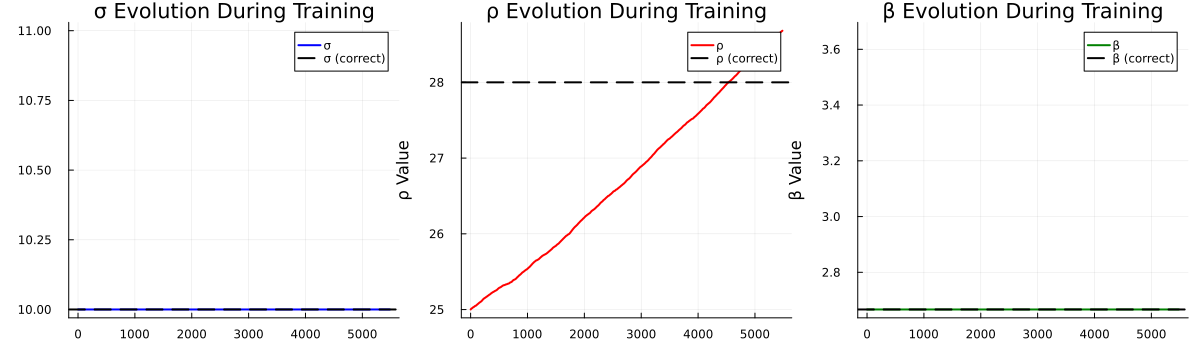

In [6]:
plot_params = plot_param_history(res_test, base_params_test)
display(plot_params)

In [ ]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 32  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ  # <- choose your target bandwidth here
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 10
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h


cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42)
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
res_test = train_statistics(
    init_params;
    target = target_pdf,
    stats  = (:pdf3d,),
    optimizer = Optimisers.Adam(1e-3),                 # <= was 3e-3
    update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
    epochs = 10_000,
    refresh = 5,                                      
    early_stopping_patience = 1500,
    early_stopping_min_delta = 1e-6,
    rel_delta = 1e-5,
    cfg = cfg_test,
    verbose = true,
    gradient_verbose = false,
    gradient_clip_norm = 5.0                           # <= was 10.0
)

println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)